## 🔥 <span style='text-decoration: double underline; color:rgb(10,110,217)'>**PyTorch: Autograd and Gradients**</span>

**Author:** Ángel Fernández Caravaca

**GitHub:** [@afdezcaravaca](https://github.com/afdezcaravaca)

**Date:** March 2026

### 📑 <span style='color:rgb(10,110,217)'><u>**Introduction:**</u></span>

#### ❓ <span style='color:rgb(10,110,217)'><u>**Why Gradients Matter in Deep Learning**</u></span>
Training a neural network is fundamentally an optimization problem. Given a model with learnable parameters **θ** and a loss function **L(θ)** that measures prediction error, the goal is to find the parameter values that minimize L. The standard algorithm for this is **gradient descent** is:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta L$$

where **η** is the learning rate and **∇θL** is the gradient of the loss with respect to every parameter. Computing these gradients manually for deep, layered architectures is intractable — this is precisely the problem that `torch.autograd` solves automatically.

---

#### 🔀 <span style='color:rgb(10,110,217)'><u>**The Computational Graph**</u></span>

Every time PyTorch executes a tensor operation involving at least one tensor with `requires_grad=True`, it silently records that operation as a node in a **directed acyclic graph (DAG)** called the **computational graph**.

- **Leaf nodes** are user-created tensors (inputs, weights, biases).
- **Interior nodes** represent the intermediate results of operations (additions, multiplications, activations).
- **Edges** encode the functional dependency between tensors.

Each interior node stores a `grad_fn` — a reference to the backward function (i.e., the local derivative rule) of the operation that created it. This graph is the data structure that makes automatic differentiation possible.

```
x ──┐
    ├──[mul]── z ──[add]── y     ← forward pass builds the graph
w ──┘
```

Because PyTorch uses a **dynamic** (Define-by-Run) graph, the structure is rebuilt from scratch on every forward pass. This means control flow (`if`, `for`, `while`) can change the graph's topology between iterations, making it suitable for architectures with variable structure.

---

#### ⏪ <span style='color:rgb(10,110,217)'><u>**Backpropagation and the Chain Rule**</u></span>

Backpropagation is an efficient algorithm for computing **all partial derivatives of a scalar loss** with respect to all parameters simultaneously, in a single backward pass over the computational graph.

It is a direct application of the **chain rule** of calculus. For a composite function $L = f(g(h(x)))$:

$$\frac{dL}{dx} = \frac{dL}{df} \cdot \frac{df}{dg} \cdot \frac{dg}{dh} \cdot \frac{dh}{dx}$$

Backpropagation traverses the computational graph from the output (the loss) back to the leaf tensors, multiplying local Jacobians at each step. This reverse traversal is triggered by calling `.backward()` on a scalar tensor.

After a call to `.backward()`, every leaf tensor with `requires_grad=True` accumulates its gradient in the `.grad` attribute:

```python
y.backward()   # triggers reverse traversal of the graph
x.grad         # ∂y/∂x — now populated
```

---

#### 📈 <span style='color:rgb(10,110,217)'><u>**Gradient Accumulation and zero_grad()**</u></span>

A critical and often surprising behaviour of PyTorch's autograd engine is that **gradients are accumulated (summed) into `.grad` across multiple `.backward()` calls** rather than overwritten.

This is intentional: in certain training paradigms (e.g., gradient accumulation over micro-batches, RNN through-time unrolling), additive gradient behaviour is required. However, in a standard training loop, it means that **failing to zero the gradients before each update will silently corrupt them**.

The fix is to call `.zero_()` on the gradient tensor (or, when using an optimizer, `optimizer.zero_grad()`) at the start of every iteration:

```python
# Incorrect — gradients grow unboundedly across steps
for _ in range(steps):
    loss.backward()
    w -= lr * w.grad

# Correct
for _ in range(steps):
    loss.backward()
    w -= lr * w.grad
    w.grad.zero_()
```

---

#### 📷 <span style='color:rgb(10,110,217)'><u>**Controlling Gradient Tracking**</u></span>

Not every computation in a training pipeline requires gradient tracking. Inference, evaluation, and manual weight updates should all be executed outside the autograd engine to avoid unnecessary memory and compute overhead.

PyTorch provides two complementary mechanisms:

##### `torch.no_grad()`
A context manager that **globally disables gradient tracking** for all operations inside the block. No `grad_fn` is attached to output tensors, and no graph is constructed. This is the standard idiom for model evaluation and manual parameter updates.

```python
with torch.no_grad():
    prediction = model(x)        # no graph built
    w -= lr * w.grad             # safe in-place update
```

##### `.detach()`
Returns a **new tensor that shares the same data** as the original but is detached from the computational graph — it has no `grad_fn` and will not propagate gradients. Unlike `no_grad()`, it operates on a single tensor rather than a code block.

```python
loss_value = loss.detach()    # extract a scalar for logging without breaking the graph
```
<div align='center'>

| Mechanism | Scope | Creates new tensor? | Use case |
|---|---|---|---|
| `torch.no_grad()` | Block-level | No | Inference, manual updates |
| `.detach()` | Tensor-level | Yes (shared data) | Logging, stopping gradient flow |
</div>

---

#### 👐 <span style='color:rgb(10,110,217)'><u>**Manual Gradient Descent**</u></span>

Before introducing `nn.Module` and optimizers, it is instructive to implement the full training loop manually. Given a simple linear model `y_hat = w * x + b` and the Mean Squared Error (MSE) loss:

$$L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

One training step consists of four operations:

1. **Forward pass** — compute predictions and loss.
2. **Backward pass** — call `loss.backward()` to populate `.grad` on all leaf tensors.
3. **Parameter update** — adjust weights using gradient descent inside a `no_grad()` block.
4. **Zero gradients** — clear `.grad` before the next iteration.

This manual loop is the conceptual foundation that PyTorch optimizers (`SGD`, `Adam`, etc.) abstract away, but understanding it is essential for diagnosing training failures.

---

#### 💤 <span style='color:rgb(10,110,217)'><u>**Higher-Order Derivatives**</u></span>

By default, the computational graph is freed after `.backward()` is called. To compute **higher-order gradients** (i.e., derivatives of derivatives), the graph of the backward pass itself must be retained, which is done by passing `create_graph=True` to `torch.autograd.grad()`:

```python
dy_dx = torch.autograd.grad(y, x, create_graph=True)[0]
d2y_dx2 = torch.autograd.grad(dy_dx, x)[0]
```

Higher-order gradients appear in several advanced Machine Learning scenarios:

- **Meta-learning (e.g., MAML):** The outer loop optimizes through the inner loop's gradient update, requiring gradients of gradients.
- **Physics-informed neural networks (PINNs):** Loss terms include differential equation residuals, demanding second or higher derivatives of the network output with respect to its inputs.
- **Penalty-based regularization:** Methods like gradient penalty in Wasserstein GANs penalize the norm of the gradient of the discriminator.

---

#### 💣 <span style='color:rgb(10,110,217)'><u>**Jacobians and Hessians**</u></span>

For vector-valued functions, the generalization of the derivative is the **Jacobian matrix**. Given $f: \mathbb{R}^n \rightarrow \mathbb{R}^m$, the Jacobian $J \in \mathbb{R}^{m \times n}$ is defined as:

$$J_{ij} = \frac{\partial f_i}{\partial x_j}$$

For scalar-valued functions of a vector input, the Jacobian reduces to a gradient vector. When the function maps vectors to vectors, the full matrix is needed.

The **Hessian** $H \in \mathbb{R}^{n \times n}$ is the matrix of second-order partial derivatives of a scalar function $g: \mathbb{R}^n \rightarrow \mathbb{R}$:

$$H_{ij} = \frac{\partial^2 g}{\partial x_i \, \partial x_j}$$

PyTorch exposes both through `torch.autograd.functional`:

```python
J = torch.autograd.functional.jacobian(f, x)
H = torch.autograd.functional.hessian(g, x)
```

The Hessian is particularly relevant in **second-order optimization methods** (Newton's method, L-BFGS) and in curvature analysis of the loss landscape.

---

#### 🤒 <span style='color:rgb(10,110,217)'><u>**Gradient Pathologies: Explosion and Clipping**</u></span>

In deep networks trained with gradient descent, two related instabilities can occur during backpropagation:

- **Vanishing gradients:** Gradients become exponentially small as they propagate back through many layers, causing early layers to learn extremely slowly or not at all. This is especially common with sigmoid/tanh activations and deep recurrent networks.
- **Exploding gradients:** Gradients become exponentially large, causing weight updates that are so large they destabilize training, often producing `NaN` losses.

**Gradient clipping** is the standard mitigation for explosion. It rescales the gradient vector to have a maximum norm of `max_norm` before the update step:

$$\text{if } \|\mathbf{g}\| > \text{max\_norm}, \quad \mathbf{g} \leftarrow \mathbf{g} \cdot \frac{\text{max\_norm}}{\|\mathbf{g}\|}$$

In PyTorch, this is a single call placed between `.backward()` and the optimizer step:

```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

Monitoring the **gradient norm per epoch** is a standard diagnostic tool for identifying instability in training.

---

#### 🎃 <span style='color:rgb(10,110,217)'><u>**Custom Autograd Functions**</u></span>

PyTorch's autograd engine can be extended with **custom differentiable operations** by subclassing `torch.autograd.Function` and implementing two static methods:

- **`forward(ctx, *inputs)`** — executes the operation and optionally saves tensors needed for the backward pass using `ctx.save_for_backward()`.
- **`backward(ctx, grad_output)`** — receives the upstream gradient and returns the local gradients with respect to each input, applying the chain rule.

```python
class MySqrt(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        result = x.sqrt()
        ctx.save_for_backward(result)
        return result

    @staticmethod
    def backward(ctx, grad_output):
        (result,) = ctx.saved_tensors
        return grad_output / (2 * result)
```

This mechanism is necessary when:

- The operation is not expressible via existing PyTorch primitives (e.g., a custom CUDA kernel).
- The analytical backward pass is more numerically stable than the one autograd would derive automatically (e.g., `log-sum-exp` tricks).
- Performance requires a fused, hand-written backward implementation.

#### ✅ <span style='color:rgb(10,110,217)'><u>**Verifying Correctness: gradcheck**</u></span>

`torch.autograd.gradcheck()` verifies that a custom backward implementation matches the numerical Jacobian computed via **finite differences**:

$$\frac{\partial f}{\partial x_i} \approx \frac{f(x + \epsilon \mathbf{e}_i) - f(x - \epsilon \mathbf{e}_i)}{2\epsilon}$$

It is the standard tool for validating any custom `autograd.Function` implementation before use in production code.


#### ✅ <span style='color:rgb(10,110,217)'><u>**Python Decorators**</u></span>

A **decorator** is a function that wraps another function to modify or extend its behavior. The `@decorator` syntax is just a function that modifies another function. this is usually referred as "syntactic sugar". For example: 

```python
@staticmethod
def forward(ctx, x): ...

# Is exactly the same as:
def forward(ctx, x): ...
forward = staticmethod(forward)
```

`@staticmethod` tells Python that a method **does not need the instance (`self`) or the class (`cls`)** — it's just a regular function that lives inside a class for organizational purposes. It can be called directly from the class without creating an object:

```python
MyClass.my_method(x)  # No instance needed
```

In PyTorch's `torch.autograd.Function`, `@staticmethod` is **mandatory**: PyTorch calls `forward` and `backward` directly from the class and uses `ctx` as a communication object between both methods, replacing the role that `self` would normally play.

- <span style='color:rgb(10,110,217)'>**Important Decorators to Know**</span>

| Decorator | Explanation | Use Cases |
|---|---|---|
| `@staticmethod` | Defines a method that doesn't receive `self` or `cls`. It's just a function namespaced inside a class. | Utility functions logically related to a class but that don't need its state. Mandatory in `torch.autograd.Function`. |
| `@classmethod` | Receives `cls` (the class itself) instead of `self`. | Alternative constructors, factory methods, accessing class-level attributes. |
| `@property` | Turns a method into a readable attribute. Avoids calling it with `()`. | Computed attributes, controlled access to internal state. |
| `@property.setter` | Defines what happens when you assign a value to a `@property`. | Input validation before storing a value. |
| `@abstractmethod` | Forces subclasses to implement the method. Must be used with `ABC`. | Defining interfaces and base classes. |
| `@dataclass` | Auto-generates `__init__`, `__repr__`, `__eq__` and more from class attributes. | Clean data containers without boilerplate code. |
| `@functools.wraps` | Used when writing custom decorators to preserve the original function's metadata. | Building your own decorators correctly. |
| `@functools.lru_cache` | Caches the results of a function so repeated calls with the same arguments are instant. | Expensive or recursive functions (e.g. Fibonacci). |
| `@torch.no_grad` | Disables gradient computation inside the block. | Model inference and evaluation loops in PyTorch. |
---


### 🐧 <span style='color:rgb(10,110,217)'><u>**Level 1: Sliding down the slope**</u></span>
Use the [official documentation](https://docs.pytorch.org/docs/stable/index.html) while solving the exercises.

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 1:**</span>
> Define `x = tensor(2.0, requires_grad=True)` and compute $y = 3x^2 + 2x - 1$. Perform backpropagation and manually verify that $\frac{dy}{dx} = 6x + 2$ evaluated at $x=2$ yields $14$.

In [1]:
import torch

# Point at which we will eval the derivative:
x = torch.tensor(2.0, requires_grad=True)
print(f'Leaf node variable: x = {x.item()}')

# Function to be differentiated:
y = 3*x**2 + 2*x - 1
print(f'Function to be differenciated: y(x) = 3*x**2 + 2*x - 1')
print(f'Result of forward propagation: y({x.item()}) = {y}')

# Load the computational graph:
y.backward()

# Compute the derivative:
derivative = x.grad
print(f"Derivative y'(x={x.item()}) = {derivative}")

Leaf node variable: x = 2.0
Function to be differenciated: y(x) = 3*x**2 + 2*x - 1
Result of forward propagation: y(2.0) = 15.0
Derivative y'(x=2.0) = 14.0


<span style='color:rgb(24, 184, 212)'>**Comment:**</span> Unlike symbolic differentiation (e.g., SymPy), PyTorch does not return an analytical expression for the derivative. Instead, `y = 3*x**2 + 2*x - 1` evaluates to a concrete number (y=15.0), while simultaneously building a computational graph that encodes the functional relationship between y and x.

When `.backward()` is called, PyTorch traverses this graph in reverse, applying exact local derivative rules at each node and accumulates the result directly at x: dy/dx evaluated at x=2 = 14. 

- <span style='color:rgb(233, 91, 9)'>**Intuitive thought:**</span> PyTorch has the derivative rules you learned in high school — power rule, product rule,
chain rule, and so on — "hardcoded" for every primitive operation it supports. 


- <span style='color:rgb(176, 27, 196)'>**What it really does:**</span>

Inspect the underlying autograd engine using torchviz. Run `pip install torchviz` and execute the following cell. Change the expression for $y$ and discuss how PyTorch dynamically alters the graph's nodes and edges in response to your mathematical modifications. (`graphviz` is required)

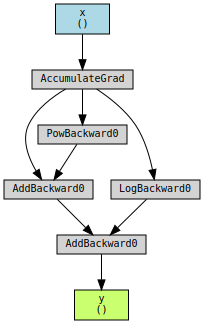

In [2]:
from torchviz import make_dot
from IPython.display import display

x = torch.tensor(2.0, requires_grad=True)
y = x**2 + x + torch.log(x)

display(make_dot(y, params={"x": x, "y": y}))

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 2:**</span>
> Given a vector `x = [1.0, 2.0, 3.0]` with `requires_grad=True`, compute $L = \sum x^2$ and obtain the gradient. What value do you expect for each element?

In [3]:
# Create tensor:
x = torch.tensor([1, 2, 3], dtype=torch.float32, requires_grad=True)
print(f'x = {x}')

# Compute L = sum(x²)
L = torch.sum(torch.pow(x,2))
print(f'L = {L.item()}')

# Load the computational graph:
L.backward()

# Compute derivate:
derivative = x.grad
print(f'dL/dx = {derivative}')

x = tensor([1., 2., 3.], requires_grad=True)
L = 14.0
dL/dx = tensor([2., 4., 6.])


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 3:**</span>
> Create `x = tensor(1.0, requires_grad=True)` and perform backpropagation twice in a loop without calling `zero_grad()` over a simple function (e.g x**2). Observe the issue. Fix it using `x.grad.zero_()` and explain why PyTorch accumulates gradients by default. (You are not computing the second derivative!)

In [4]:
# Create the tensor:
x = torch.tensor(1.0, requires_grad=True)

# Compute the same derivative two times without zero_grad()
print('--- Without zero_grad() ---')
for i in range(2):
    y = x ** 2          
    y.backward()       
    print(f"{i+1}º grad: {x.grad}") # It should return 1º grad: 2.0; 2º grad: 2.0, but...
x.grad.zero_() 

print("--- With zero_grad() ---")
for i in range(2):
         
    y = x ** 2
    y.backward()
    print(f"{i+1}º  grad: {x.grad}")
    x.grad.zero_() 


--- Without zero_grad() ---
1º grad: 2.0
2º grad: 4.0
--- With zero_grad() ---
1º  grad: 2.0
2º  grad: 2.0


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 4:**</span>
> Simulate a training step: 
> - Define the weights as `w=0.5`, `b=0.0` and `lr=0.1`. Do they require gradients by default?
> - Define `x = torch.linspace(0,1, 20)` and compute `y_true = 3*x +2` and `y_pred = w*x + b`. What do you expect the updated values of w and b to be?
> - Compute the MSE loss and display the computational graph. 
> - Perform backpropagation, and manually update the weights using the following approaches, **in order**:
>    - Compute `w = w - lr * w.grad`. Display the computational graph. What is the difference compared to the previous one? 
>    - Inside a `try` block, compute `w -= lr * w.grad`. What error do you get? This explains the difference between the two graphs.
>    - Compute `w.data -= lr*w.grad` and display the computational graph. What has accessing `.data` changed?
>    - Finally, update the weights inside a `torch.no_grad()` block and display the graph. Notice how the graph is restored to its original clean state.
> - Use `.detach()` to extract a tensor value without its computation history. Add a comment explaining when you would use `.detach()` vs `torch.no_grad()`.

**Explanation:**

`.detach()` vs `torch.no_grad()`:

- **`.detach()`** acts on a **single, already-existing tensor**: it returns a view of that tensor with no gradient history. The rest of the graph is untouched. Typical use cases are logging, computing metrics, or converting to NumPy — anywhere you need to *extract* a value without carrying its computation history.

- **`torch.no_grad()`** is a **context manager** that prevents any *new* operations performed inside it from being tracked by autograd at all. Nothing is extracted from an existing graph — rather, no graph is built in the first place. This is the standard approach for inference loops and parameter updates.

In short: use `.detach()` when you want to **pull one tensor out** of an existing graph; use `torch.no_grad()` when you want an entire **block of operations** to be invisible to autograd from the start.

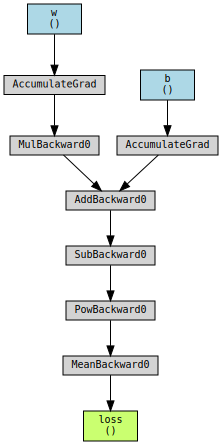

In [5]:
# Define the weights --> They are learnable parameters, so they required graphs:
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01 # This one does not require gradients.
# Create a problem: 
x = torch.linspace(0,1, 20)
y_true = 3*x + 2
y_pred = w*x + b # They should update to w = 3 and b = 2

# Loss + display
loss = ((y_pred - y_true)**2).mean()
display(make_dot(loss, {'w':w, 'b':b, 'loss':loss}))

--- Before uptdate ---
Loss = 11.1382
w = 0.5
b = 0.0
--- After the Update ---
New w = 0.5371052622795105
New b = 0.0650000050663948


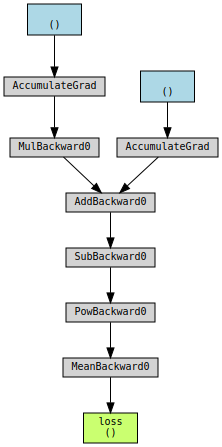

In [6]:
# Backprop with w = w - lr*w.grad

# print previous w and b:
print('--- Before uptdate ---')
loss_value = loss.detach()
w_value = w.detach()
b_value = b.detach()
print(f'Loss = {loss_value:.4f}')
print(f'w = {w_value}')
print(f'b = {b_value}')

loss.backward()
w = w - lr*w.grad
b = b - lr*b.grad
print('--- After the Update ---')
print(f'New w = {w.item()}')
print(f'New b = {b.item()}')

# Display:
display(make_dot(loss, {'w':w, 'b':b, 'loss':loss}))

Here we lost the `w` and `b` leaf nodes. This is because the update step
(`w = w - lr*w.grad`) creates new tensors that are the result of an operation,
so they are no longer leaf nodes. The variable `w` and `b` now point to these
new tensors, which are not part of the original computation graph of `loss`.

In [7]:
# Define the weights --> They are learnable parameters, so they required graphs:
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01 # This one does not require gradients.
# Create a problem: 
x = torch.linspace(0,1, 20)
y_true = 3*x + 2
y_pred = w*x + b # They should update to w = 3 and b = 2

# Loss + display
loss = ((y_pred - y_true)**2).mean()
loss.backward()
# Try for the update:
try:
    w -= lr*w.grad
    b -= lr*b.grad
except RuntimeError as e:
    print(f'RuntimeError: {e}')

RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.


As stated above, `w -=lr*w.grad` creates new tensors, so they are no longer leaf nodes. In contrast to previous cell, an explicit error is return.

--- Before uptdate ---
Loss = 11.1382
w = 0.5
b = 0.0
--- After the Update ---
New w = 0.5371
New b = 0.0650


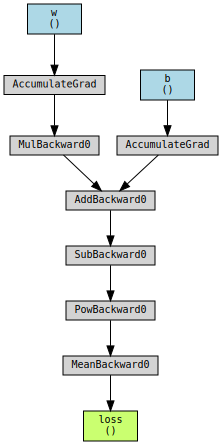

In [8]:
# Backprop with w.data:

# Define the weights --> They are learnable parameters, so they required graphs:
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01 # This one does not require gradients.

# Create a problem: 
x = torch.linspace(0,1, 20)
y_true = 3*x + 2
y_pred = w*x + b # They should update to w = 3 and b = 2

# Loss + display
loss = ((y_pred - y_true)**2).mean()

loss.backward()

# Update:
print('--- Before uptdate ---')
loss_value = loss.detach()
w_value = w.detach()
b_value = b.detach()
print(f'Loss = {loss_value:.4f}')
print(f'w = {w_value}')
print(f'b = {b_value}')

w.data -= lr*w.grad
b.data -= lr*b.grad

print('--- After the Update ---')
w_value = w.detach()
b_value = b.detach()
print(f'New w = {w_value:.4f}')
print(f'New b = {b_value:.4f}')

display(make_dot(loss, {'w':w, 'b':b, 'loss':loss}))

While modifying `tensor.data` might conceptually seem like a quick way to update weights without recording the operation in the computational graph, it is a deprecated and highly dangerous practice in production. 

The reason for this is that using `.data` completely bypasses PyTorch's `autograd` version control and safety checks. In particular:

* **Memory Corruption:** When you execute `w.data -= ...`, you are rewriting the underlying memory without notifying the framework.
* **Loss of Graph Integrity:** `autograd` remains unaware that the tensor's value has changed. With `.data`, it notices it.
* **Silent Poisoning:** If that modified tensor is used in subsequent forward passes or gradient calculations, `autograd` will use the obsolete state. This results in **mathematically incorrect gradients**. The code will not crash; it will simply fail to converge or learn incorrect patterns silently.

**The Standard Best Practice:** `torch.no_grad()`


--- Before uptdate ---
Loss = 11.1382
w = 0.5
b = 0.0
--- After the Update ---
New w = 0.5371052622795105
New b = 0.0650000050663948


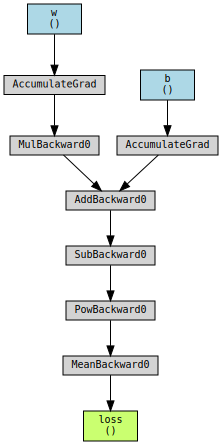

In [9]:
# Backprop with w.data:

# Define the weights --> They are learnable parameters, so they required graphs:
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01 # This one does not require gradients.

# Create a problem: 
x = torch.linspace(0,1, 20)
y_true = 3*x + 2
y_pred = w*x + b # They should update to w = 3 and b = 2

# Loss + display
loss = ((y_pred - y_true)**2).mean()
loss.backward()

# Update:
print('--- Before uptdate ---')
loss_value = loss.detach()
w_value = w.detach()
b_value = b.detach()
print(f'Loss = {loss_value:.4f}')
print(f'w = {w_value}')
print(f'b = {b_value}')

with torch.no_grad():
    w -= lr*w.grad
    b -= lr*b.grad

print('--- After the Update ---')
print(f'New w = {w.item()}')
print(f'New b = {b.item()}')

display(make_dot(loss, {'w':w, 'b':b, 'loss':loss}))

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 5:**</span>
> Without using `nn.Module`, define `w` and `b` as 0-dimensional tensors with `requires_grad=True`. Generate a dataset of 100 samples using $x \sim \text{Uniform}(0,1)$ and synthetic labels $y = 2x + 1 + \varepsilon$ where $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Train for 100 epochs using MSE loss and a learning rate of `lr = 0.1`. After each backward pass, update the parameters manually inside a `torch.no_grad()` block and zero the gradients by hand. Print the loss every 10 epochs and verify that `w` converges to $\sim 2$, `b` to $\sim 1$.

In [10]:
torch.manual_seed(42)
# Define w and b:
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

learning_rate = 0.1

# Synthetic data:
x = torch.rand(100)
epsilon = torch.randn(100) * 0.1
y_true = 2*x + 1 + epsilon

# Train:
epochs = 100
for i in range(epochs):
    y_pred = w*x + b
    loss = ((y_pred - y_true)**2).mean()

    if (i % 10 == 0) or (i == epochs - 1):
        print(f'--- Epoch {i} ---')
        loss_value = loss.detach()
        w_value = w.detach()
        b_value = b.detach()

        print(f'Loss: {loss_value:.4f}')
        print(f'W = {w_value:.4f}')
        print(f'b = {b_value:.4f}')

    loss.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
        w.grad.zero_()
        b.grad.zero_()

--- Epoch 0 ---
Loss: 3.3317
W = 0.5000
b = 0.0000
--- Epoch 10 ---
Loss: 0.0461
W = 1.3195
b = 1.2801
--- Epoch 20 ---
Loss: 0.0302
W = 1.4320
b = 1.3068
--- Epoch 30 ---
Loss: 0.0246
W = 1.4993
b = 1.2741
--- Epoch 40 ---
Loss: 0.0204
W = 1.5566
b = 1.2426
--- Epoch 50 ---
Loss: 0.0171
W = 1.6067
b = 1.2150
--- Epoch 60 ---
Loss: 0.0147
W = 1.6504
b = 1.1908
--- Epoch 70 ---
Loss: 0.0128
W = 1.6886
b = 1.1697
--- Epoch 80 ---
Loss: 0.0113
W = 1.7220
b = 1.1512
--- Epoch 90 ---
Loss: 0.0102
W = 1.7512
b = 1.1351
--- Epoch 99 ---
Loss: 0.0094
W = 1.7743
b = 1.1223


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 6:**</span>
> Define `x = torch.tensor(1.0, requires_grad=True)` and compute $y = \log(\sigma(x^2))$,
> where $\sigma$ is the sigmoid function. Perform backpropagation and print `x.grad`.
> Then manually apply the chain rule to derive $\frac{dy}{dx}$ and evaluate it at $x = 1.0$.
> Confirm both values match using `torch.isclose()`.

In [11]:
# Torch chain rule:
x = torch.tensor(1.0, requires_grad=True)
y = torch.log(torch.sigmoid(x**2))

y.backward()
print(f'Derivative with x.grad = {x.grad:.4f}')

# Manual chain rule:
diff = 2*x/(torch.exp(x**2) +1)
print(f'Manual differentiation: {diff:.4f}')

# Is close:
print(f'Do they match?\n{torch.isclose(x.grad, diff).item()}')

Derivative with x.grad = 0.5379
Manual differentiation: 0.5379
Do they match?
True


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 7:**</span>
> Compute the second derivative of $y = x^4 - 3x^2$ at $x = 2.0$ using `torch.autograd.grad()` with `create_graph=True`. Verify the result analytically. When would higher-order gradients be useful in Machine Learning?

* **Second-order optimization:** Hessian matrices for curvature (e.g., Newton's method).
* **Meta-learning (MAML):** Backpropagating through inner-loop gradient steps.
* **Regularization:** Penalizing gradient norms (e.g., WGAN-GP).
* **PINNs:** Loss functions embedding partial differential equations.
* **Hyperparameter tuning:** Differentiating validation loss w.r.t hyperparameters.
* **Uncertainty estimation:** Inverse Hessian for Laplace approximations.

In [12]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.pow(x, 4) - 3*torch.pow(x, 2)

# First derivative:
dy_dx = torch.autograd.grad(y,x, create_graph=True)
print(f'1º derivative (autograd): {dy_dx[0]:.4f}')
print(f'1º derivative (analytically): {(4*x**3 - 6*x):.4f}')

# Second derivative:
dy2_dx2 = torch.autograd.grad(dy_dx[0], x, create_graph=True)
print(f'2º derivative (autograd): {dy2_dx2[0]:.4f}')
print(f'2º derivative (analytically): {(12*x**2 - 6):.4f}')

1º derivative (autograd): 20.0000
1º derivative (analytically): 20.0000
2º derivative (autograd): 42.0000
2º derivative (analytically): 42.0000


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 8:**</span>
> Given an input vector $x = [1.0, 2.0, 3.0]$ and the function $f(x) = [x_1^2, x_1 x_2, x_3^3]$, compute the full Jacobian matrix using `torch.autograd.functional.jacobian()`. Then, compute the Hessian of $g(x) = x_1^2 + 2x_2^2 + x_3^2$. **Hint:** f(x) and g(x) are defined as lambda functions.

In [13]:
x = torch.tensor([1,2,3], dtype=torch.float32, requires_grad=True)
f = lambda x: torch.stack([x[0]**2, x[0]*x[1], x[2]**3])
g = lambda x: x[0]**2 + 2*x[1]**2 + x[2]**2

jacob = torch.autograd.functional.jacobian(f, x)
hess = torch.autograd.functional.hessian(g,x)
print(jacob)
print(hess)

tensor([[ 2.,  0.,  0.],
        [ 2.,  1.,  0.],
        [ 0.,  0., 27.]])
tensor([[2., 0., 0.],
        [0., 4., 0.],
        [0., 0., 2.]])


##### <span style='color:rgb(10,110,217)'>🔢**Exercise 9:**</span>
> Train a small fully-connected network with 3 `nn.Linear` layers with `nn.ReLU` activations on synthetic regression data (200 samples, 10 input features, 1 output). Use SGD with a deliberately high learning rate (`lr = 10.0`) and train for 80 epochs.
>
> First, train **without** gradient clipping and observe how the gradient norm and loss behave. Then, repeat the experiment **three times**, applying `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)` after `loss.backward()` and before `optimizer.step()`, using `max_norm ∈ {10.0, 1.0, 0.1}`.
>
> In each run, record the **global gradient norm** returned by `clip_grad_norm_()` (which reflects the norm *before* clipping) and the **MSE loss**, both per epoch. Finally, plot two subplots side by side:
> - **Left:** MSE loss per epoch for all 4 configurations.
> - **Right:** Gradient norm per epoch (log scale) for all 4 configurations.
>
> Compare training stability across configurations and explain the trade-off between a very small `max_norm` (slow learning) and no clipping at all (divergence).

- **Hint:** 
    - Architecture: 10 → Linear(10,64) → ReLU() → Linear(64,64) → ReLU() → Linear (64,1)
    - Loss:         `nn.MSELoss`
    - Optimizer:    `torch.optim.SGD`

In [14]:
import pandas as pd

# Data:
torch.manual_seed(42)
X = torch.randn(200, 10)
y = torch.randn(200, 1)

df_X = pd.DataFrame(X.numpy(), columns=[f"x{i+1}" for i in range(10)])
df_y = pd.DataFrame(y.numpy(), columns=["y"])
dataframe = pd.concat([df_X, df_y], axis=1)

dataframe

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,1.926915,1.487284,0.900717,-2.105521,0.678418,-1.234545,-0.043067,-1.604667,-0.752135,1.648723,-0.992757
1,-0.392479,-1.403607,-0.727881,-0.559430,-0.768839,0.762445,1.642317,-0.159597,-0.497398,0.439589,-0.255756
2,-0.758131,1.078318,0.800801,1.680621,1.279124,1.296423,0.610466,1.334738,-0.231624,0.041759,-0.958570
3,-0.251575,0.859859,-1.384674,-0.871236,-0.223366,1.717361,0.318880,-0.424519,0.305721,-0.774593,-0.570275
4,-1.557572,0.995636,-0.879786,-0.601142,-1.274151,2.122785,-1.234653,-0.487914,-0.913823,-0.658137,0.192817
...,...,...,...,...,...,...,...,...,...,...,...
195,1.443667,0.196146,-0.833257,-0.952684,-0.363669,-1.247925,-0.092614,0.653364,0.163699,1.345614,-0.667007
196,-0.369537,-0.471416,0.477922,0.850947,0.368844,1.062230,1.763923,-0.048380,0.912708,-1.390617,0.287722
197,-0.709612,0.930798,-0.424322,-0.482174,0.477377,-0.178998,0.493735,0.561208,-1.798656,-0.607846,-0.854220
198,-0.587634,-0.345177,-0.728777,-1.495753,0.735095,-0.269319,0.450859,0.040917,-0.069333,0.258576,0.750013


In [15]:
import torch.nn as nn
torch.manual_seed(42)
# Loss, epochs and learning rate:
loss_fn = nn.MSELoss()
epochs = 80
lr = 10

# Configs:
configs = {"No clipping": None, 
           "max_norm = 10": 10, 
           "max_norm = 1.0": 1.0,
           "max_norm = 0.1": 0.1}

# Train of each config:
results = {}
for key, max_norm in configs.items():
    # Create the model for the config:
    model = nn.Sequential(nn.Linear(10, 64), nn.ReLU(),
                       nn.Linear(64,64), nn.ReLU(),
                       nn.Linear(64,1))
    
    # Optimizer:
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # List for saving the data:
    losses, grad_norms = [], []
    print(f'Starting training with {key}')
    for epoch in range(epochs):
        
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        
        if max_norm is not None:
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm).item()
        else:
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float('inf')).item()
        
        optimizer.step()

        losses.append(loss.item())
        grad_norms.append(total_norm)
        if epoch % 10 == 0 or epoch == epochs - 1 :
            print(f'Epoch {epoch} ----->  Loss: {loss.item():.4f}   ;   Grad_Norm: {total_norm}')
    results[key] = {'loss':losses,'grad_norm':grad_norms}

Starting training with No clipping
Epoch 0 ----->  Loss: 0.9953   ;   Grad_Norm: 0.858018159866333
Epoch 10 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 20 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 30 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 40 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 50 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 60 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 70 ----->  Loss: nan   ;   Grad_Norm: nan
Epoch 79 ----->  Loss: nan   ;   Grad_Norm: nan
Starting training with max_norm = 10
Epoch 0 ----->  Loss: 0.9639   ;   Grad_Norm: 0.8588319420814514
Epoch 10 ----->  Loss: 4473683.0000   ;   Grad_Norm: 2109432.5
Epoch 20 ----->  Loss: 7758.7305   ;   Grad_Norm: 176.15699768066406
Epoch 30 ----->  Loss: 7758.7212   ;   Grad_Norm: 176.15687561035156
Epoch 40 ----->  Loss: 7758.7212   ;   Grad_Norm: 176.15687561035156
Epoch 50 ----->  Loss: 7758.7212   ;   Grad_Norm: 176.15687561035156
Epoch 60 ----->  Loss: 7758.7212   ;   Grad_Norm: 176.15687561035156
Epoch 7

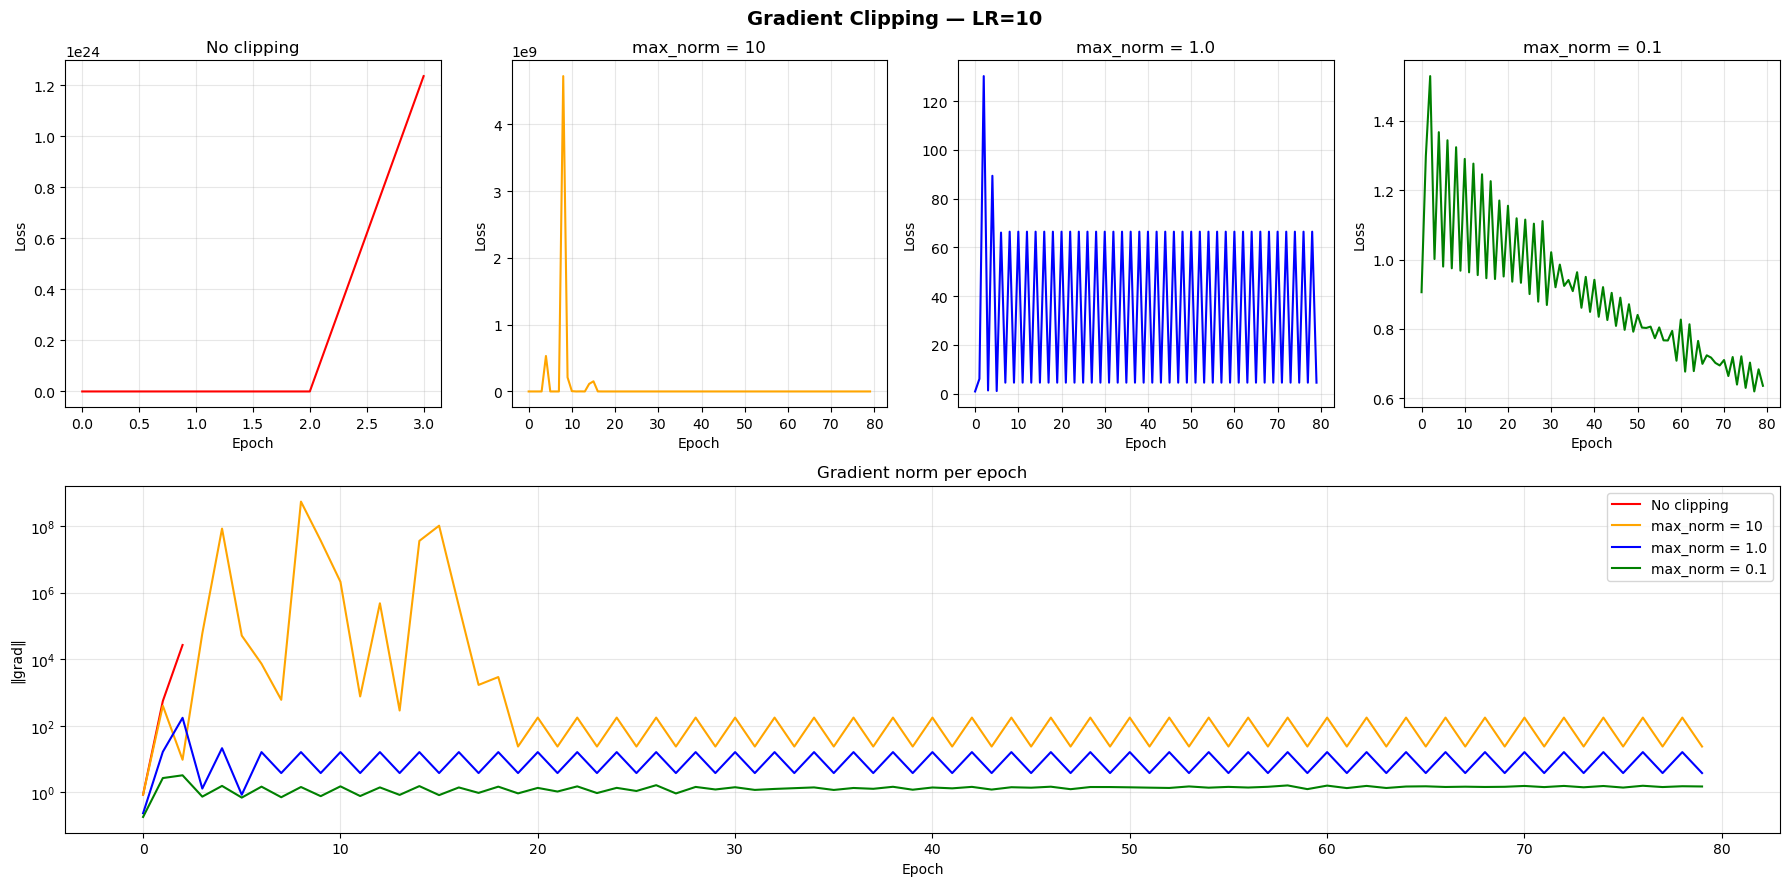

In [16]:
import matplotlib.pyplot as plt
epoch_range = range(len(results["No clipping"]["loss"]))

colors = {"No clipping":   "red", 
          "max_norm = 10":  "orange", 
          "max_norm = 1.0": "blue", 
          "max_norm = 0.1": "green"}

fig = plt.figure(figsize=(18, 9))
fig.suptitle(f"Gradient Clipping — LR={lr}", fontsize=14, fontweight="bold")

for i, (label, data) in enumerate(results.items()):
    ax = fig.add_subplot(2, 4, i + 1)
    ax.plot(epoch_range, data["loss"], color=colors[label])
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)


ax_grad = fig.add_subplot(2, 1, 2)
for label, data in results.items():
    ax_grad.plot(epoch_range, data["grad_norm"], label=label, color=colors[label])
ax_grad.set_title("Gradient norm per epoch")
ax_grad.set_xlabel("Epoch")
ax_grad.set_ylabel("‖grad‖")
ax_grad.set_yscale("log")
ax_grad.legend()
ax_grad.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style='color:rgb(10,110,217)'>**Reading the plots**</span> 
**No clipping (red):** The loss explodes to ~$10^{24}$ and the run dies at epoch ~3 — the network is completely broken. The gradient norm hits ~$10^4$ almost instantly.

**max_norm = 10 (orange):** Still unstable. The loss spikes to ~$10^9$ in the first epochs, then collapses near zero — but the gradient norm stays chaotic and large (~10²). The network "survives" by luck, not by learning.

**max_norm = 1.0 (blue):** The loss oscillates wildly between 0 and 80 for all 80 epochs — the gradient norm is capped at ~1, but lr=10 is still too aggressive. It never converges.

**max_norm = 0.1 (green):** The only config that actually learns. Loss drops from ~2.5 and trends downward, with some oscillation. Gradient norm stays tightly bounded near 1.

##### <span style='color:rgb(10,110,217)'>**What is gradient clipping?**</span> 


During backpropagation, gradients can grow exponentially through deep networks — especially with high learning rates or long sequences. When you call:

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
```

PyTorch computes the **global gradient norm** across all parameters:

$$\|g\| = \sqrt{\sum_{p} \|g_p\|^2}$$

If $\|g\| > \text{max\_norm}$, it rescales **all gradients** proportionally so the norm equals exactly `max_norm`:

$$g \leftarrow g \cdot \frac{\text{max\_norm}}{\|g\|}$$

The **direction** of the gradient is preserved — only its magnitude is reduced.

##### <span style='color:rgb(10,110,217)'>**Why does it matter?**</span> 

Without clipping, a single bad update can send weights to extreme values, making every subsequent gradient even larger — a feedback loop called **gradient explosion**. Clipping acts as a safety valve: it lets the network take large steps when gradients are small, but prevents catastrophic updates when they spike. This is especially critical in:

- RNNs and LSTMs (long sequences amplify gradients through time)
- High learning rate schedules
- Early training when weights are randomly initialized and unstable

The trade-off shown in your plot: too large a `max_norm` doesn't help (orange, blue), too small slows learning but at least keeps it stable (green). In practice you'd also **lower the learning rate** alongside clipping.

##### <span style='color:rgb(10,110,217)'>🔢**Exercise 10:**</span>
> Implement your own SoftPlus activation function $f(x) = \log(1 + e^x)$ by subclassing `torch.autograd.Function` with custom `forward()` and `backward()` methods. Verify that the gradient is mathematically correct by comparing it with `torch.autograd.gradcheck()`.

In [ ]:
# 1. Custom SoftPlus via torch.autograd.Function
class SoftPlusFunction(torch.autograd.Function):

    @staticmethod 
    def forward(ctx, x):
        # f(x) = log(1 + e^x)
        ctx.save_for_backward(x)
        return torch.log(1 + torch.exp(x))

    @staticmethod
    def backward(ctx, grad_output):
        # f'(x) = e^x / (1 + e^x) = sigmoid(x)
        x, = ctx.saved_tensors
        grad_input = torch.sigmoid(x)
        return grad_output * grad_input   # chain rule


# Wrapper as nn.Module (optional but convenient)
class SoftPlus(nn.Module):
    def forward(self, x):
        return SoftPlusFunction.apply(x)


# Manual verification
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0], requires_grad=True)

custom_out  = SoftPlusFunction.apply(x)
pytorch_out = torch.nn.functional.softplus(x)

print("Custom  :", custom_out.detach())
print("PyTorch :", pytorch_out.detach())
print("Match   :", torch.allclose(custom_out, pytorch_out))

# Gradient check  --> gradcheck requires float64 and small tensors
x_check = torch.randn(5, dtype=torch.float64, requires_grad=True)

passed = torch.autograd.gradcheck(
    SoftPlusFunction.apply,
    x_check,
    eps=1e-6,    # numerical perturbation for finite differences
    atol=1e-4,   # absolute tolerance
    rtol=1e-3    # relative tolerance
)

print(f"\nGradcheck passed: {passed}")

Custom  : tensor([0.1269, 0.3133, 0.6931, 1.3133, 2.1269])
PyTorch : tensor([0.1269, 0.3133, 0.6931, 1.3133, 2.1269])
Match   : True

Gradcheck passed: True



---

### 🎌<span style='color:rgb(10,110,217)'><u>**Summary**</u></span>

`torch.autograd` is the mathematical engine that makes end-to-end differentiable programming possible in PyTorch. The topics covered in this notebook — from the mechanics of the computational graph and backpropagation, through gradient accumulation, controlled tracking, and higher-order derivatives, to custom operations — form the complete conceptual toolkit required to understand, debug, and extend any gradient-based training procedure.